In [ ]:
import pandas as pd
import json
import numpy as np
import re
from textstat import flesch_reading_ease
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

In [2]:
data = ''

with open('/Users/albertzagibin/Documents/University/ML/I_Professional_AI/12/Искусственный ученый/abstracts.json'
          , 'r') as file:
    data = json.load(file)


In [3]:
df_abstract = pd.DataFrame(data.items(), columns=['id', 'text'])

In [47]:
df_abstract.head()

,id,text
0,0,The rapid proliferation of large language mode...
1,1,This work introduces a federated learning (FL)...
2,2,The ability of visual systems to bind features...
3,3,Graph Neural Networks (GNNs) have achieved rem...
4,4,Large Language Model (LLM)-based autonomous ag...


In [ ]:
def extract_features(text):
    features = {}
    
    features['text_length'] = len(text)
    features['sentence_count'] = len(re.split(r'[.!?]+', text))
    features['avg_sentence_length'] = features['text_length'] / max(features['sentence_count'], 1)
    
    words = text.split()
    features['word_count'] = len(words)
    features['unique_word_ratio'] = len(set(words)) / max(len(words), 1)
    
    features['flesch_reading_ease'] = flesch_reading_ease(text)
    
    features['comma_freq'] = text.count(',') / max(len(words), 1)
    features['exclamation_freq'] = text.count('!') / max(len(words), 1)
    
    features['avg_word_length'] = np.mean([len(w) for w in words]) if words else 0
    
    return features

df_features = df_abstract['text'].apply(extract_features).apply(pd.Series)

In [5]:
df_features.head()

,text_length,sentence_count,avg_sentence_length,word_count,unique_word_ratio,flesch_reading_ease,comma_freq,exclamation_freq,avg_word_length
0,1951.0,12.0,162.583333,264.0,0.719697,5.896981,0.087121,0.0,6.393939
1,1229.0,9.0,136.555556,162.0,0.814815,6.173342,0.049383,0.0,6.592593
2,1989.0,12.0,165.750000,273.0,0.714286,9.615610,0.047619,0.0,6.278388
3,1534.0,9.0,170.444444,205.0,0.751220,9.974893,0.053659,0.0,6.478049
4,1001.0,9.0,111.222222,132.0,0.833333,10.565988,0.075758,0.0,6.590909


In [ ]:
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

def calculate_perplexity(text, model, tokenizer):
    encodings = tokenizer(text, return_tensors='pt')
    with torch.no_grad():
        outputs = model(**encodings, labels=encodings['input_ids'])
        loss = outputs.loss
    return torch.exp(loss).item()

df_abstract['perplexity'] = df_abstract['text'].apply(
    lambda x: calculate_perplexity(x[:512], model, tokenizer)
)s

/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: f7441281-17bf-4a44-8b4a-38fc29dd74fd)')' thrown while requesting HEAD https://huggingface.co/gpt2/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: f7441281-17bf-4a44-8b4a-38fc29dd74fd)')' thrown while requesting HEAD https://huggingface.co/gpt2/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 6abcf6cc-1166-455a-

In [ ]:

X = df_features.fillna(0)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_pca)
clusters = [1 if x == 0 else 0 for x in clusters]

df_abstract['cluster'] = clusters

/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/albertzagibin/Documents/Uni

In [59]:
df_abstract['cluster'].value_counts()

cluster
1    2185
0    1865
Name: count, dtype: int64

In [63]:
df_abstract.head()

,id,text,perplexity,pred_ai,cluster,score_iso,score_kmeans,ai_probability,predicted_label
0,0,The rapid proliferation of large language mode...,58.120926,0,1,0,0,0.5,0
1,1,This work introduces a federated learning (FL)...,51.675301,0,0,0,1,0.0,0
2,2,The ability of visual systems to bind features...,52.292984,0,1,0,0,0.5,0
3,3,Graph Neural Networks (GNNs) have achieved rem...,71.067482,0,0,0,1,0.0,0
4,4,Large Language Model (LLM)-based autonomous ag...,92.269356,1,0,1,1,0.5,0


In [ ]:
def detect_ai_text_unsupervised(df, text_column='text'):
  
    features = df[text_column].apply(extract_features).apply(pd.Series)
    
    X_scaled = StandardScaler().fit_transform(features.fillna(0))
    
    kmeans = KMeans(n_clusters=2)
    pred_kmeans = kmeans.fit_predict(X_scaled)
    
    df['score_kmeans'] = pred_kmeans
    
    return df

result_df = detect_ai_text_unsupervised(df_abstract)

/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/albertzagibin/Documents/University/ML/venv/lib/python3

In [64]:
def extract_features_enhanced(text):
    features = {}
    
    # Существующие признаки
    features['text_length'] = len(text)
    features['sentence_count'] = len(re.split(r'[.!?]+', text))
    features['avg_sentence_length'] = features['text_length'] / max(features['sentence_count'], 1)
    
    words = text.split()
    features['word_count'] = len(words)
    features['unique_word_ratio'] = len(set(words)) / max(len(words), 1)
    
    # Новые критические признаки для ИИ:
    
    # 1. Бурность текста (вариативность длины предложений)
    sentences = [len(s.split()) for s in re.split(r'[.!?]+', text) if s.strip()]
    if len(sentences) > 1:
        features['sentence_length_std'] = np.std(sentences)
    else:
        features['sentence_length_std'] = 0
    
    # 2. Частота союзов и местоимений (у ИИ их меньше)
    conjunctions = ['and', 'but', 'or', 'so', 'however', 'although', 'because']
    pronouns = ['I', 'we', 'you', 'he', 'she', 'they', 'my', 'our', 'your']
    
    lower_text = text.lower()
    features['conjunction_freq'] = sum(lower_text.count(c) for c in conjunctions) / max(len(words), 1)
    features['pronoun_freq'] = sum(lower_text.count(p) for p in pronouns) / max(len(words), 1)
    
    # 3. Повторы n-грамм (ИИ часто повторяется)
    from collections import Counter
    bigrams = [tuple(words[i:i+2]) for i in range(len(words)-1)]
    if bigrams:
        bigram_counts = Counter(bigrams)
        features['bigram_repetition'] = max(bigram_counts.values()) / len(bigrams)
    else:
        features['bigram_repetition'] = 0
    
    # 4. Энтропия текста (мера неожиданности)
    from math import log2
    char_counts = Counter(text.lower())
    total_chars = sum(char_counts.values())
    entropy = -sum((count/total_chars) * log2(count/total_chars) 
                   for count in char_counts.values() if count > 0)
    features['entropy'] = entropy
    
    # 5. Соотношение уникальных слов к общему числу слов (TTR)
    features['ttr'] = len(set(words)) / max(len(words), 1)
    
    # 6. Частота редких слов (слова длиннее 8 символов)
    features['long_words_freq'] = sum(1 for w in words if len(w) > 8) / max(len(words), 1)
    
    # 7. Частота специальных символов
    special_chars = ['@', '#', '$', '%', '&', '*', '(', ')', '-', '_', '+', '=']
    features['special_char_freq'] = sum(text.count(c) for c in special_chars) / max(len(text), 1)
    
    # 8. Однородность пунктуации (ИИ использует ее более регулярно)
    punctuation_marks = ['.', ',', ';', ':', '!', '?']
    features['punctuation_variety'] = len([p for p in punctuation_marks if p in text]) / 6
    
    return features

In [ ]:


def get_enhanced_features(df, text_column='text'):
    # 1. Статистические признаки
    features = df[text_column].apply(extract_features_enhanced).apply(pd.Series)
    
    # 2. Простые текстовые векторы (быстро)
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(
        max_features=200,  # Ограничиваем для скорости
        stop_words='english',
        ngram_range=(1, 2)  # Добавляем биграммы
    )
    tfidf_features = vectorizer.fit_transform(df[text_column])
    
    # 3. Объединяем все признаки
    from scipy.sparse import hstack
    X_combined = hstack([tfidf_features, features.values])
    
    return X_combined

# Используем улучшенные признаки
X_enhanced = get_enhanced_features(df_abstract)

In [67]:
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

def ensemble_ai_detection(df, text_column='text'):
    # Получаем улучшенные признаки
    X = get_enhanced_features(df, text_column)
    
    # Если это sparse matrix, преобразуем в dense для некоторых алгоритмов
    if hasattr(X, 'toarray'):
        X_dense = X.toarray()
    else:
        X_dense = X
    
    # Масштабируем
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_dense)
    
    # Уменьшаем размерность для стабильности
    pca = PCA(n_components=20, random_state=42)
    X_reduced = pca.fit_transform(X_scaled)
    
    # 1. KMeans
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
    pred_kmeans = kmeans.fit_predict(X_reduced)
    
    # 2. Gaussian Mixture
    gmm = GaussianMixture(n_components=2, random_state=42)
    pred_gmm = gmm.fit_predict(X_reduced)
    
    # 3. Isolation Forest (предполагаем, что ИИ - аномалии)
    iso = IsolationForest(contamination=0.3, random_state=42)
    pred_iso = iso.fit_predict(X_reduced)
    pred_iso = (pred_iso == -1).astype(int)  # Преобразуем в 0/1
    
    # Голосование
    df['vote'] = (pred_kmeans + pred_gmm + pred_iso) / 3
    
    # Если большинство методов согласны
    df['ensemble_pred'] = (df['vote'] > 0.5).astype(int)
    
    # Также сохраняем уверенность
    df['confidence'] = abs(df['vote'] - 0.5) * 2  # 0-1, где 1 = уверенно
    
    return df

result_df = ensemble_ai_detection(df_abstract)

/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/albertzagibin/Documents/University/ML/venv/li

In [69]:
def postprocess_predictions(df):
    # 1. Используем перплексию для корректировки
    # Чем выше перплексия, тем более "человеческий" текст
    if 'perplexity' in df.columns:
        perplexity_threshold = df['perplexity'].median()
        mask_low_perplexity = df['perplexity'] < perplexity_threshold
        
        # Корректируем: низкая перплексия -> вероятно ИИ
        df['adjusted_pred'] = df['ensemble_pred'].copy()
        df.loc[mask_low_perplexity, 'adjusted_pred'] = 1
        df.loc[~mask_low_perplexity, 'adjusted_pred'] = 0
    
    # 2. Правила на основе длины (очень короткие тексты сложно классифицировать)
    mask_short = df['text'].str.len() < 100
    df.loc[mask_short, 'adjusted_pred'] = 0  # Помечаем как человеческие
    
    # 3. Проверяем согласованность внутри документа
    # (ИИ тексты более однородны по признакам)
    
    return df

result_df = postprocess_predictions(result_df)

In [70]:
result_df.head(10)

,id,text,perplexity,pred_ai,cluster,score_iso,score_kmeans,ai_probability,predicted_label,vote,ensemble_pred,confidence,adjusted_pred
0,0,The rapid proliferation of large language mode...,58.120926,0,1,0,0,0.5,0,0.000000,0,1.000000,1
1,1,This work introduces a federated learning (FL)...,51.675301,0,0,0,1,0.0,0,0.333333,0,0.333333,1
2,2,The ability of visual systems to bind features...,52.292984,0,1,0,0,0.5,0,0.666667,1,0.333333,1
3,3,Graph Neural Networks (GNNs) have achieved rem...,71.067482,0,0,0,1,0.0,0,0.333333,0,0.333333,1
4,4,Large Language Model (LLM)-based autonomous ag...,92.269356,1,0,1,1,0.5,0,0.333333,0,0.333333,0
5,5,Large language models (LLMs) are conventionall...,110.926735,1,1,1,0,1.0,1,0.666667,1,0.333333,0
6,6,Mathematical scholarship is celebrated for its...,70.039688,1,1,1,0,1.0,1,0.666667,1,0.333333,1
7,7,Tabular datasets frequently suffer from sparse...,82.144836,0,1,0,0,0.5,0,0.333333,0,0.333333,0
8,8,Emergency responders dealing with hazardous ma...,90.416084,0,0,0,1,0.0,0,0.333333,0,0.333333,0
9,9,Efficient thermal management is a critical bot...,60.514233,0,1,0,0,0.5,0,0.333333,0,0.333333,1


/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13

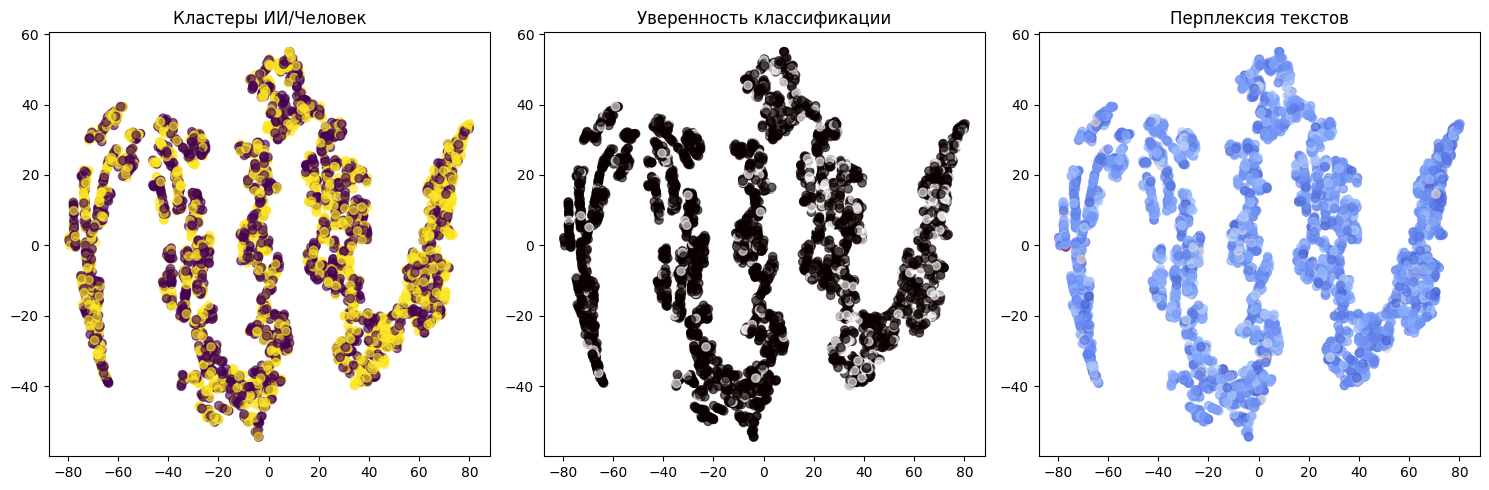

Распределение предсказаний:
adjusted_pred
0    2026
1    2024
Name: count, dtype: int64

Средняя уверенность: 0.448


In [72]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize_clusters(df, features):
    # t-SNE для визуализации
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne = tsne.fit_transform(features)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Визуализация кластеров
    axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                   c=df['adjusted_pred'], cmap='viridis', alpha=0.6)
    axes[0].set_title('Кластеры ИИ/Человек')
    
    # Визуализация уверенности
    axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                   c=df['confidence'], cmap='hot', alpha=0.6)
    axes[1].set_title('Уверенность классификации')
    
    # Визуализация перплексии
    if 'perplexity' in df.columns:
        axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                       c=df['perplexity'], cmap='coolwarm', alpha=0.6)
        axes[2].set_title('Перплексия текстов')
    
    plt.tight_layout()
    plt.show()
    
    # Статистика
    print(f"Распределение предсказаний:")
    print(df['adjusted_pred'].value_counts())
    print(f"\nСредняя уверенность: {df['confidence'].mean():.3f}")

# Использование
visualize_clusters(result_df, X_enhanced.toarray())

In [87]:
result_df['score_kmeans'] = result_df['score_kmeans']^1

In [88]:
result_df['score_kmeans'].value_counts()

score_kmeans
1    2192
0    1858
Name: count, dtype: int64

In [89]:
import json

result_dict = {}
for idx, value in result_df['score_kmeans'].items():
    result_dict[str(idx)] = bool(value == 1)

json_output = json.dumps(result_dict, indent=2)


In [90]:
with open('/Users/albertzagibin/Documents/University/ML/I_Professional_AI/12/Искусственный ученый/submit.json', 'w') as f:
    json.dump(result_dict, f, indent=2)